In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("INTERPRETABILIDAD CON SHAP VALUES")
print("=" * 60)

# Cargar datos
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

# Cargar modelos
with open("../results/models/logistic_regression.pkl", "rb") as f:
    lr_model = pickle.load(f)

xgb_model = xgb.XGBClassifier()
xgb_model.load_model("../results/models/xgboost_model.json")

print(f"\n✅ Datos y modelos cargados")
print(f"   X_test: {X_test.shape}")

INTERPRETABILIDAD CON SHAP VALUES

✅ Datos y modelos cargados
   X_test: (200, 20)


In [2]:
print("\n" + "=" * 60)
print("SHAP VALUES - XGBOOST")
print("=" * 60)

# Crear explicador SHAP para XGBoost
print(f"\n🔄 Calculando SHAP values...")
explainer = shap.TreeExplainer(xgb_model)

# Calcular SHAP values (usar sample de test para visualización)
X_test_sample = X_test.sample(min(100, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print(f"✅ SHAP values calculados")
print(f"   Shape: {shap_values.shape}")


SHAP VALUES - XGBOOST

🔄 Calculando SHAP values...
✅ SHAP values calculados
   Shape: (100, 20)



📊 SUMMARY PLOT (Importancia Global)


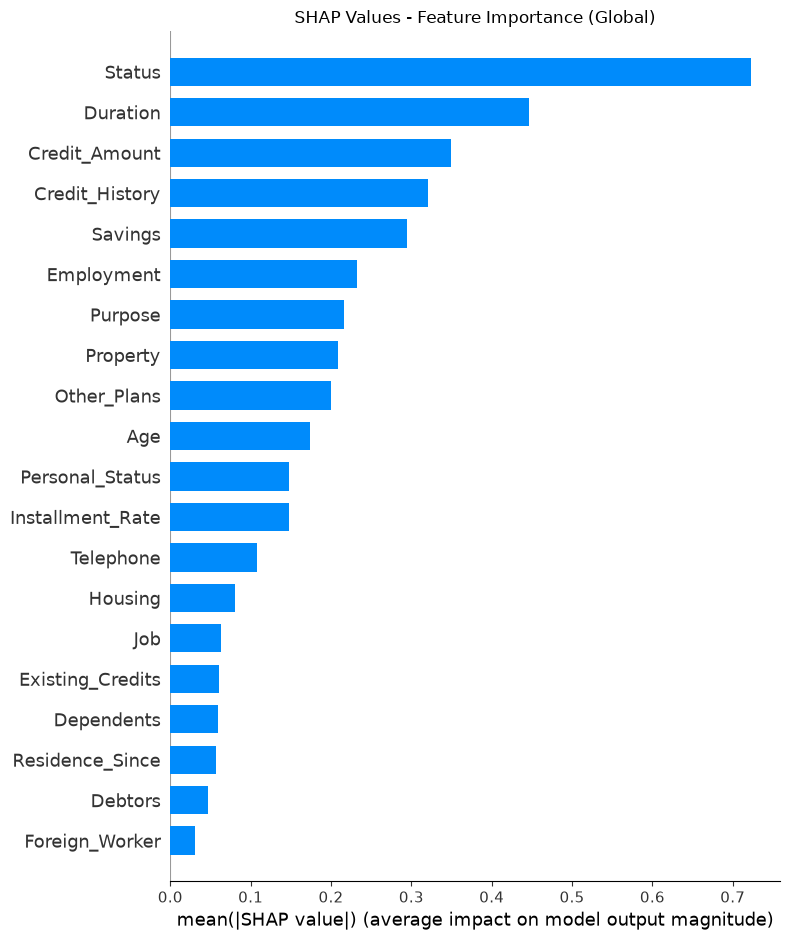

✅ Summary plot generado


In [3]:
# Summary plot - Importancia global de features
print(f"\n📊 SUMMARY PLOT (Importancia Global)")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Values - Feature Importance (Global)")
plt.tight_layout()
plt.show()

print("✅ Summary plot generado")


📊 DEPENDENCE PLOTS (Top 4 Features)
Top 4 features más importantes:
  - Status: 0.7227
  - Duration: 0.4465
  - Credit_Amount: 0.3488
  - Credit_History: 0.3208


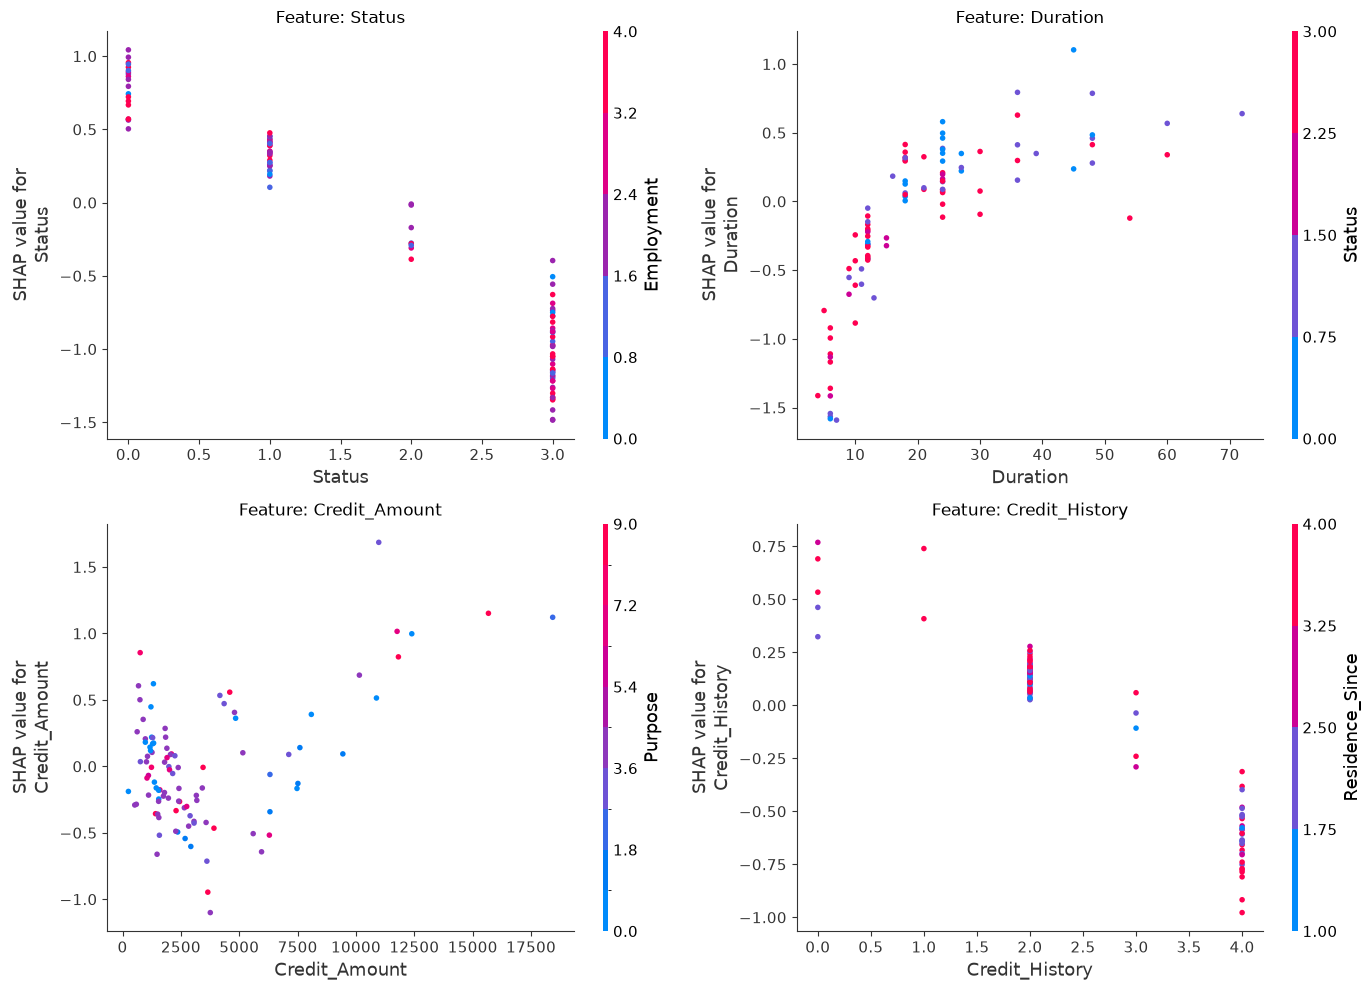

✅ Dependence plots generados


In [5]:
# Dependence plots para las 4 features más importantes
print(f"\n📊 DEPENDENCE PLOTS (Top 4 Features)")

# Obtener feature importance desde SHAP values
shap_importance = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(shap_importance)[-4:][::-1]

print(f"Top 4 features más importantes:")
for idx in top_features_idx:
    print(f"  - {X_test_sample.columns[idx]}: {shap_importance[idx]:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature_idx in enumerate(top_features_idx):
    feature_name = X_test_sample.columns[feature_idx]
    
    shap.dependence_plot(
        feature_idx, shap_values, X_test_sample,
        ax=axes[idx], show=False
    )
    axes[idx].set_title(f"Feature: {feature_name}")

plt.tight_layout()
plt.show()

print("✅ Dependence plots generados")


COMPARACIÓN: SHAP vs Feature Importance Tradicional

Top 10 features por SHAP importance:
       Feature  XGBoost_Importance  SHAP_Importance
        Status            0.134513         0.722658
      Duration            0.055654         0.446470
 Credit_Amount            0.045212         0.348817
Credit_History            0.059874         0.320801
       Savings            0.062945         0.295102
    Employment            0.040378         0.232849
       Purpose            0.037418         0.216259
      Property            0.050123         0.208360
   Other_Plans            0.064099         0.199512
           Age            0.039122         0.173606


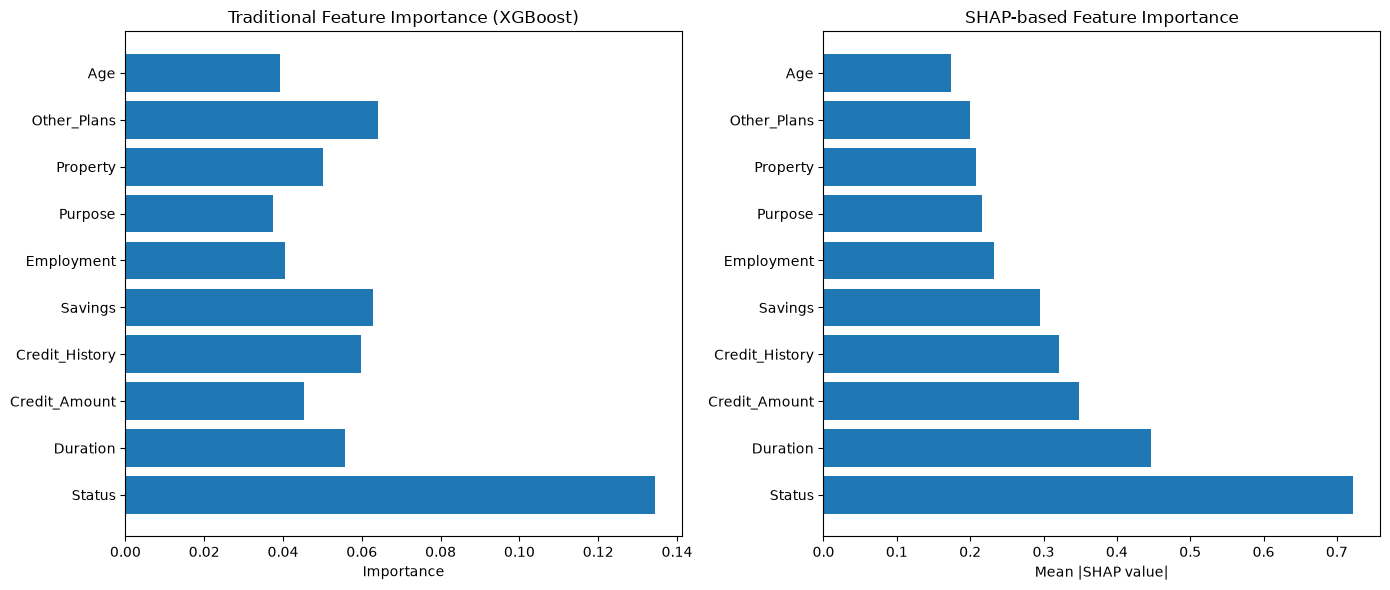


💡 DIFERENCIA:
   - Traditional Importance: ¿Qué features usa más el modelo?
   - SHAP Importance: ¿Qué features más cambian las predicciones?


In [6]:
print("\n" + "=" * 60)
print("COMPARACIÓN: SHAP vs Feature Importance Tradicional")
print("=" * 60)

# Feature importance tradicional (XGBoost)
traditional_importance = xgb_model.feature_importances_

# SHAP importance (promedio de |SHAP values|)
shap_importance = np.abs(shap_values).mean(axis=0)

# Crear DataFrame para comparación
importance_comparison = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'XGBoost_Importance': traditional_importance,
    'SHAP_Importance': shap_importance
}).sort_values('SHAP_Importance', ascending=False)

print("\nTop 10 features por SHAP importance:")
print(importance_comparison.head(10).to_string(index=False))

# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(importance_comparison['Feature'][:10], 
             importance_comparison['XGBoost_Importance'][:10])
axes[0].set_xlabel('Importance')
axes[0].set_title('Traditional Feature Importance (XGBoost)')

axes[1].barh(importance_comparison['Feature'][:10],
             importance_comparison['SHAP_Importance'][:10])
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('SHAP-based Feature Importance')

plt.tight_layout()
plt.show()

print("\n💡 DIFERENCIA:")
print("   - Traditional Importance: ¿Qué features usa más el modelo?")
print("   - SHAP Importance: ¿Qué features más cambian las predicciones?")

In [7]:
print("\n" + "=" * 60)
print("RESUMEN DE INTERPRETABILIDAD")
print("=" * 60)

print(f"""
✅ SHAP Values Analysis Completado

📊 Qué aprendimos:

1. SUMMARY PLOT (Bar Plot):
   - Muestra la importancia promedio de cada feature
   - Features que más impacto tienen en las predicciones

2. DEPENDENCE PLOTS:
   - Muestran la relación entre feature value y SHAP value
   - Útil para entender relaciones no-lineales

3. FORCE PLOT:
   - Explicación individual para cada predicción
   - Muestra qué features "empujan" la predicción hacia Good/Bad

4. SHAP vs Traditional Importance:
   - SHAP es más interpretable para reguladores
   - Explica cada predicción, no solo importancia global

📋 Aplicación a Riesgo de Crédito (PD Modeling):
   - Reguladores (CNBV, Basel III) requieren explicabilidad
   - SHAP values son el estándar industria
   - Puedes explicar cualquier decisión de crédito
   - Cumple con requisitos de transparencia y governance

🎯 Ventajas para tu Perfil:
   - Demostraste expertise en riesgo + ML moderno
   - SHAP values = diferenciador clave en mercado
   - Preparado para presentar a reclutadores
""")

print("✅ Interpretabilidad completada")


RESUMEN DE INTERPRETABILIDAD

✅ SHAP Values Analysis Completado

📊 Qué aprendimos:

1. SUMMARY PLOT (Bar Plot):
   - Muestra la importancia promedio de cada feature
   - Features que más impacto tienen en las predicciones

2. DEPENDENCE PLOTS:
   - Muestran la relación entre feature value y SHAP value
   - Útil para entender relaciones no-lineales

3. FORCE PLOT:
   - Explicación individual para cada predicción
   - Muestra qué features "empujan" la predicción hacia Good/Bad

4. SHAP vs Traditional Importance:
   - SHAP es más interpretable para reguladores
   - Explica cada predicción, no solo importancia global

📋 Aplicación a Riesgo de Crédito (PD Modeling):
   - Reguladores (CNBV, Basel III) requieren explicabilidad
   - SHAP values son el estándar industria
   - Puedes explicar cualquier decisión de crédito
   - Cumple con requisitos de transparencia y governance

🎯 Ventajas para tu Perfil:
   - Demostraste expertise en riesgo + ML moderno
   - SHAP values = diferenciador clave e